In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import least_squares
from mpl_toolkits.mplot3d import Axes3D

## Funciones

In [3]:

def delta_suave(theta, d1, d2, d3, d4):

    th = np.mod(theta, 2*np.pi)

    theta_nodes = np.array([
        0,
        np.pi/2,
        np.pi,
        3*np.pi/2,
        2*np.pi
    ])

    delta_nodes = np.array([
        d1,
        d2,
        d3,
        d4,
        d1
    ])

    return np.interp(
        th,
        theta_nodes,
        delta_nodes
    )


def model_angulo(
    theta,
    S0,
    S1,
    S2,
    S3,
    d1,
    d2,
    d3,
    d4,
    theta0,
):

    theta = theta + theta0

    delta = delta_suave(
        theta,
        d1,
        d2,
        d3,
        d4
    )

    a0 = (
        S0/2
        + S1/4*(1 + np.cos(delta))
    )

    a4c = (
        S1/4*(1 - np.cos(delta))
    )

    a4s = (
        S2/4*(1 - np.cos(delta))
    )

    a2 = (
        -S3/2*np.sin(delta)
    )

    return (
        a0
        + a2*np.sin(2*theta)
        + a4c*np.cos(4*theta)
        + a4s*np.sin(4*theta)
    )

In [4]:
#theta fijo y deltas libres
def fit_una_vuelta_angulo_thetafijo(theta, I, theta0_fijo, titulo=""):

    if titulo != "":
        print(f"\n========== {titulo} ==========\n")

    # =========================================
    # ordenar
    # =========================================

    idx = np.argsort(theta)

    theta = theta[idx]
    I = I[idx]

    # =========================================
    # normalizar
    # =========================================

    I = I / np.max(I)

    S0 = np.max(I)

    # =========================================
    # errores
    # =========================================

    V_div = 0.005

    V_full_scale = 8 * V_div

    res_err = V_full_scale / 256

    I_err = np.sqrt(
        (0.03 * I)**2
        + res_err**2
    )

    # =========================================
    # residuals
    # =========================================

    def residuals(params):

        (
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4
        ) = params

        I_model = model_angulo(
            theta,
            S0,
            S1,
            S2,
            S3,
            d1,
            d2,
            d3,
            d4,
            theta0_fijo
        )

        return (
            I_model - I
        ) / I_err

    # =========================================
    # bounds
    # =========================================

    lower_bounds = [
        -S0,
        -S0,
        -S0,
        1.50,
        1.50,
        1.50,
        1.50,]

    upper_bounds = [
        S0,
        S0,
        S0,
        1.60,
        1.60,
        1.60,
        1.60,]

    # =========================================
    # multistart
    # =========================================

    best_result = None
    best_cost = np.inf

    for _ in range(20):

        guess = [

        np.random.uniform(-S0, S0),
        np.random.uniform(-S0, S0),
        np.random.uniform(-S0, S0),

        np.random.uniform(1.50, 1.60),
        np.random.uniform(1.50, 1.60),
        np.random.uniform(1.50, 1.60),
        np.random.uniform(1.50, 1.60)]
        
        r = least_squares(
            residuals,
            guess,
            bounds=(
                lower_bounds,
                upper_bounds
            )
        )

        if r.cost < best_cost:

            best_cost = r.cost
            best_result = r

    result = best_result


    J = result.jac

    N = len(theta)
    P = len(result.x)

    sigma2 = 2 * result.cost / (N - P)

    cov = sigma2 * np.linalg.pinv(J.T @ J)

    err = np.sqrt(np.diag(cov))

    (
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit
    ) = result.x

    theta0_fit=theta0_fijo

    # =========================================
    # curva ajustada
    # =========================================

    theta_fit = np.linspace(
        0,
        2*np.pi,
        3000
    )

    I_fit = model_angulo(
        theta_fit,
        S0,
        S1_fit,
        S2_fit,
        S3_fit,
        d1_fit,
        d2_fit,
        d3_fit,
        d4_fit,
        theta0_fit
    )

        # =========================================
    # PLOT AJUSTE
    # =========================================

    plt.figure(figsize=(8,5))
    plt.title(titulo)
    plt.plot(
        theta,
        I,
        "o",
        ms=4,
        label="Datos"
    )

    plt.plot(
        theta_fit,
        I_fit,
        lw=2,
        label="Ajuste"
    )

    plt.xlabel(r"$\theta$ [rad]")
    plt.ylabel("Intensidad normalizada")
    plt.grid(True)
    plt.legend()

    # =========================================
    # ESFERA DE POINCARE
    # =========================================

    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection="3d")

    # esfera
    u = np.linspace(0,2*np.pi,60)
    v = np.linspace(0,np.pi,30)

    x = np.outer(np.cos(u),np.sin(v))
    y = np.outer(np.sin(u),np.sin(v))
    z = np.outer(np.ones_like(u),np.cos(v))

    ax.plot_wireframe(
        x,
        y,
        z,
        color="lightgray",
        linewidth=0.5
    )

    # ejes
    ax.plot([-1,1],[0,0],[0,0],'k')
    ax.plot([0,0],[-1,1],[0,0],'k')
    ax.plot([0,0],[0,0],[-1,1],'k')

    # punto medido
    s1 = S1_fit / S0
    s2 = S2_fit / S0
    s3 = S3_fit / S0

    DOP = np.sqrt(
    s1**2 +
    s2**2 +
    s3**2)

    err_s1 = err[0] / S0
    err_s2 = err[1] / S0
    err_s3 = err[2] / S0

    err_DOP = np.sqrt((s1/DOP * err_s1)**2 +(s2/DOP * err_s2)**2 +(s3/DOP * err_s3)**2)

    ax.scatter(
        s1,
        s2,
        s3,
        color="red",
        s=80
    )

    ax.plot(
        [0,s1],
        [0,s2],
        [0,s3],
        color="red"
    )

    ax.set_xlabel(r"$S_1/S_0$")
    ax.set_ylabel(r"$S_2/S_0$")
    ax.set_zlabel(r"$S_3/S_0$")

    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])

    ax.set_box_aspect((1,1,1))


    resultados = {

        "s1": s1,
        "s2": s2,
        "s3": s3,

        "err_s1": err_s1,
        "err_s2": err_s2,
        "err_s3": err_s3,

        "DOP": DOP,
        "err_DOP": err_DOP,
        "d1": d1_fit,
        "d2": d2_fit,
        "d3": d3_fit,
        "d4": d4_fit,

        "err_d1": err[3],
        "err_d2": err[4],
        "err_d3": err[5],
        "err_d4": err[6],

        "theta0": theta0_fijo,
        "theta_fit": theta_fit,
        "err_theta0": 0
    }

    print("\n========== VECTOR DE POINCARÉ ==========")
    print(f"S1/S0 = {s1:.5f} ± {err_s1:.5f}")
    print(f"S2/S0 = {s2:.5f} ± {err_s2:.5f}")
    print(f"S3/S0 = {s3:.5f} ± {err_s3:.5f}")
    print(f"\nDOP = {DOP:.5f} ± {err_DOP:.5f}")

    print("\n========== DELTAS ==========")
    print(f"δ1 = {d1_fit:.5f} ± {err[3]:.5f} rad")
    print(f"δ2 = {d2_fit:.5f} ± {err[4]:.5f} rad")
    print(f"δ3 = {d3_fit:.5f} ± {err[5]:.5f} rad")
    print(f"δ4 = {d4_fit:.5f} ± {err[6]:.5f} rad")

    print(f"\nθ0 = {theta0_fijo:.5f} ± {0} rad")

    return resultados

## Analizo

### 0

In [5]:
ruta = r"C:\Users\barcr\OneDrive\Documents\Polarimetro\med2_0"

dfs= []

for i in range(0, 48, 3):

    nombre = f"{ruta}\\bloque_{i:04d}_{i+2:04d}.csv"

    dfs.append(pd.read_csv(nombre))



========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 1.00000 ± 0.35691
S2/S0 = 0.00038 ± 0.70130
S3/S0 = -0.00218 ± 0.32662

DOP = 1.00000 ± 0.35691

========== DELTAS ==========
δ1 = 1.50000 ± 1.39907 rad
δ2 = 1.50000 ± 1.39948 rad
δ3 = 1.50000 ± 1.39806 rad
δ4 = 1.50000 ± 1.39714 rad

θ0 = 0.00000 ± 0 rad

========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.33911 ± 0.05595
S2/S0 = 0.01791 ± 0.09940
S3/S0 = 0.01320 ± 0.04900

DOP = 0.33984 ± 0.05611

========== DELTAS ==========
δ1 = 1.50000 ± 0.72313 rad
δ2 = 1.50000 ± 0.72197 rad
δ3 = 1.50000 ± 0.62414 rad
δ4 = 1.50000 ± 0.61987 rad

θ0 = 0.00000 ± 0 rad

========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.56095 ± 0.06206
S2/S0 = -0.00725 ± 0.10977
S3/S0 = -0.00063 ± 0.05243

DOP = 0.56100 ± 0.06207

========== DELTAS ==========
δ1 = 1.50000 ± 0.48774 rad
δ2 = 1.50000 ± 0.43732 rad
δ3 = 1.50000 ± 0.41046 rad
δ4 = 1.5000

C:\Users\barcr\AppData\Local\Temp\ipykernel_20608\3919341246.py:181: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8,5))



========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.31977 ± 0.05759
S2/S0 = 0.02545 ± 0.09937
S3/S0 = -0.00563 ± 0.05140

DOP = 0.32083 ± 0.05794

========== DELTAS ==========
δ1 = 1.50000 ± 0.78129 rad
δ2 = 1.50000 ± 0.80698 rad
δ3 = 1.50000 ± 0.69283 rad
δ4 = 1.60000 ± 0.67009 rad

θ0 = 0.00000 ± 0 rad

========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.32276 ± 0.05715
S2/S0 = 0.02902 ± 0.10053
S3/S0 = 0.00885 ± 0.05086

DOP = 0.32419 ± 0.05762

========== DELTAS ==========
δ1 = 1.50000 ± 0.77424 rad
δ2 = 1.50000 ± 0.78462 rad
δ3 = 1.50000 ± 0.67661 rad
δ4 = 1.54655 ± 0.66277 rad

θ0 = 0.00000 ± 0 rad

========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.36670 ± 0.05749
S2/S0 = 0.01538 ± 0.10191
S3/S0 = 0.00522 ± 0.05031

DOP = 0.36706 ± 0.05759

========== DELTAS ==========
δ1 = 1.50000 ± 0.68301 rad
δ2 = 1.50000 ± 0.68530 rad
δ3 = 1.50000 ± 0.59184 rad
δ4 = 1.50000 ± 0.58741 rad

θ0 = 0.00000 ± 0 rad

===

C:\Users\barcr\AppData\Local\Temp\ipykernel_20608\3919341246.py:140: RuntimeWarning: invalid value encountered in sqrt
  err = np.sqrt(np.diag(cov))



========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.99959 ± nan
S2/S0 = 0.00193 ± nan
S3/S0 = -0.00036 ± nan

DOP = 0.99960 ± nan

========== DELTAS ==========
δ1 = 1.50022 ± nan rad
δ2 = 1.50009 ± -0.00000 rad
δ3 = 1.54390 ± nan rad
δ4 = 1.58402 ± nan rad

θ0 = 0.00000 ± 0 rad

========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.30466 ± 0.05426
S2/S0 = 0.04741 ± 0.09351
S3/S0 = -0.01586 ± 0.04796

DOP = 0.30873 ± 0.05549

========== DELTAS ==========
δ1 = 1.50000 ± 0.75795 rad
δ2 = 1.50000 ± 0.78422 rad
δ3 = 1.50000 ± 0.67891 rad
δ4 = 1.60000 ± 0.65146 rad

θ0 = 0.00000 ± 0 rad

========== Bloque angulo 0 ==========


========== VECTOR DE POINCARÉ ==========
S1/S0 = 0.32027 ± 0.05940
S2/S0 = 0.04698 ± 0.10242
S3/S0 = -0.01367 ± 0.05348

DOP = 0.32398 ± 0.06061

========== DELTAS ==========
δ1 = 1.50000 ± 0.78629 rad
δ2 = 1.50000 ± 0.83939 rad
δ3 = 1.50000 ± 0.71690 rad
δ4 = 1.60000 ± 0.67463 rad

θ0 = 0.00000 ± 0 rad


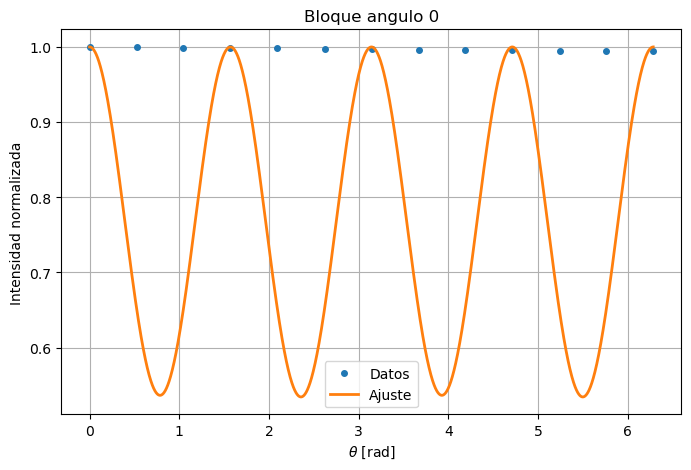

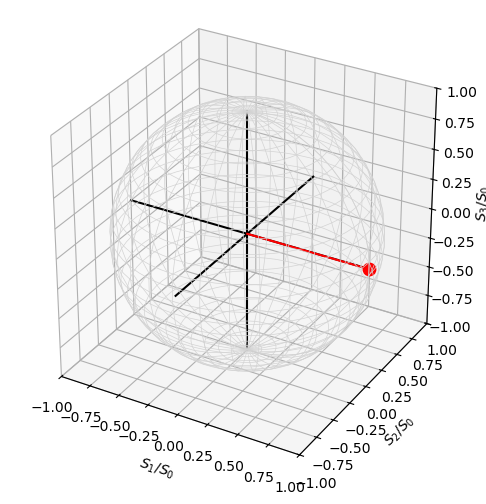

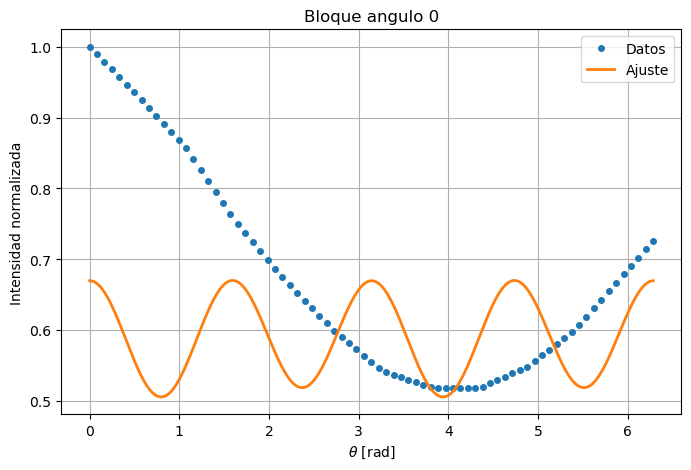

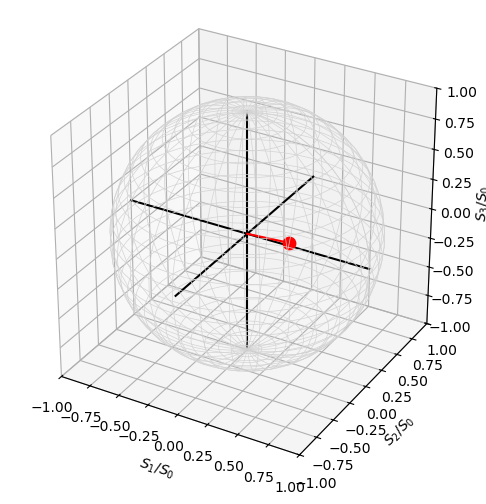

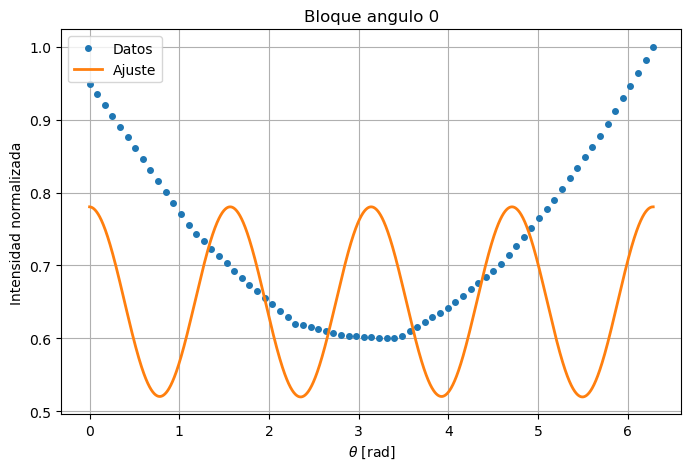

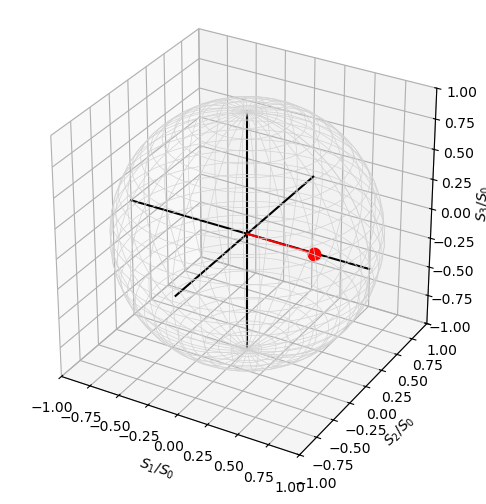

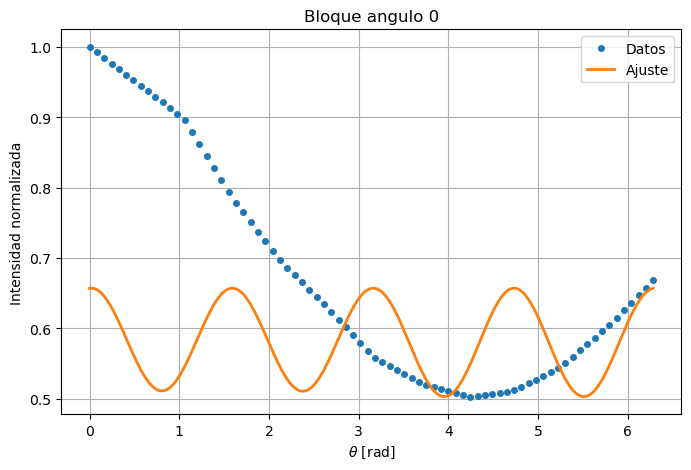

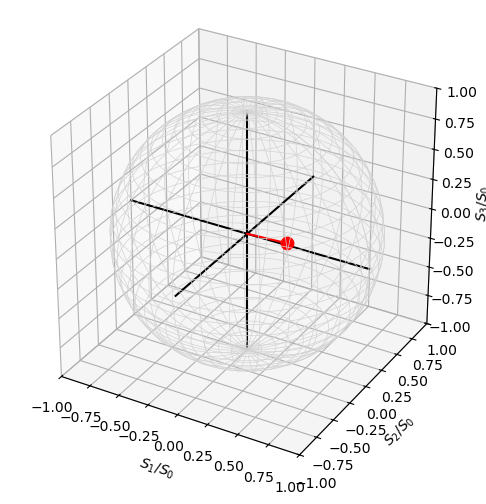

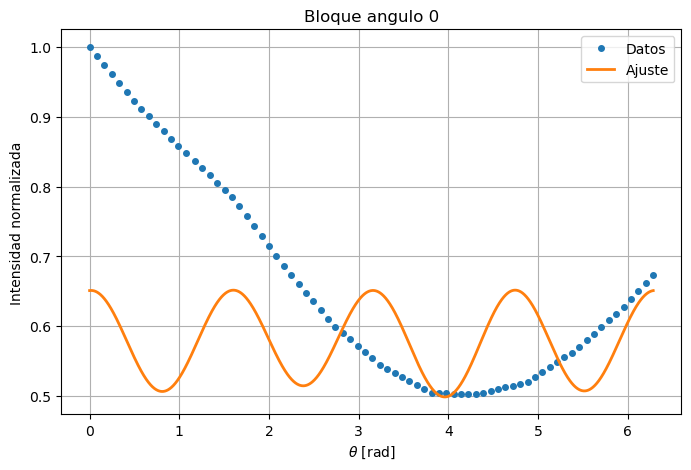

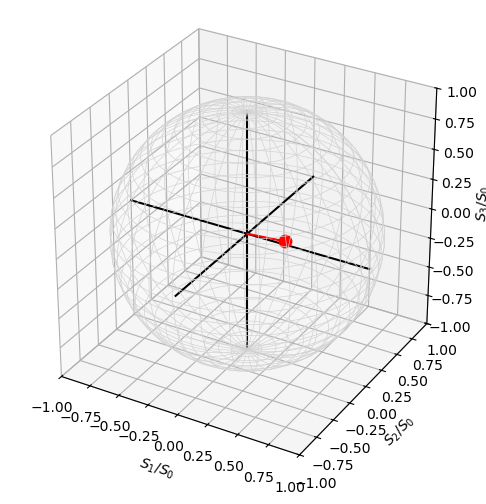

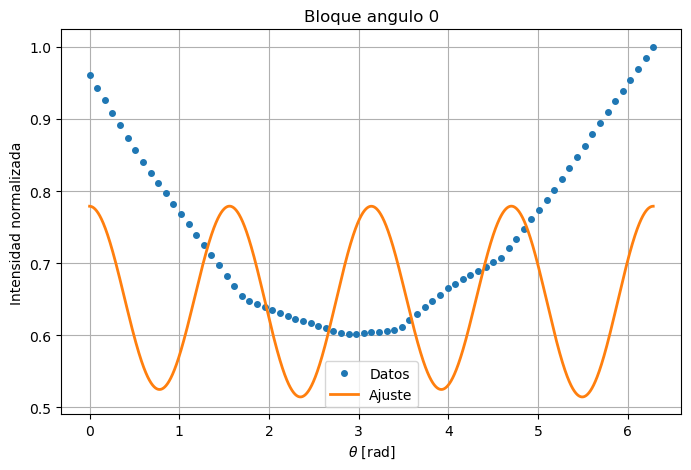

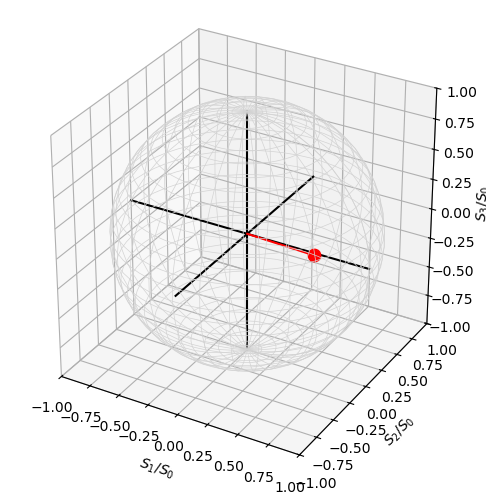

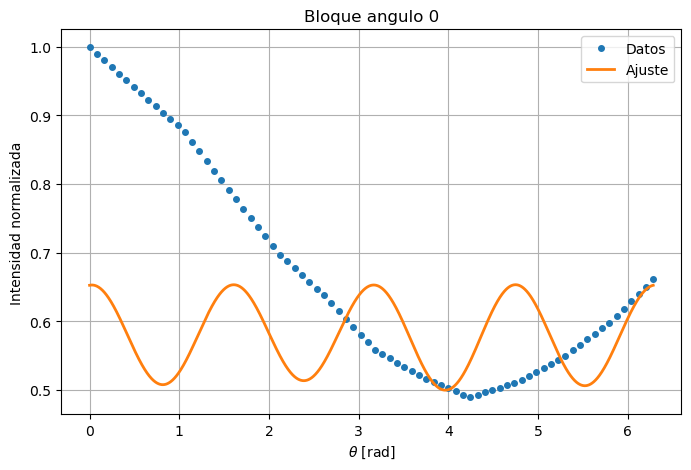

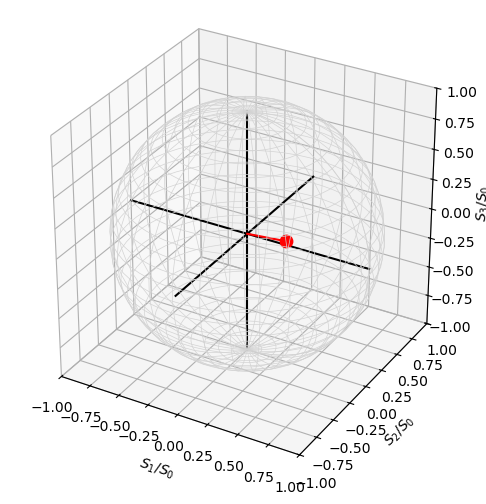

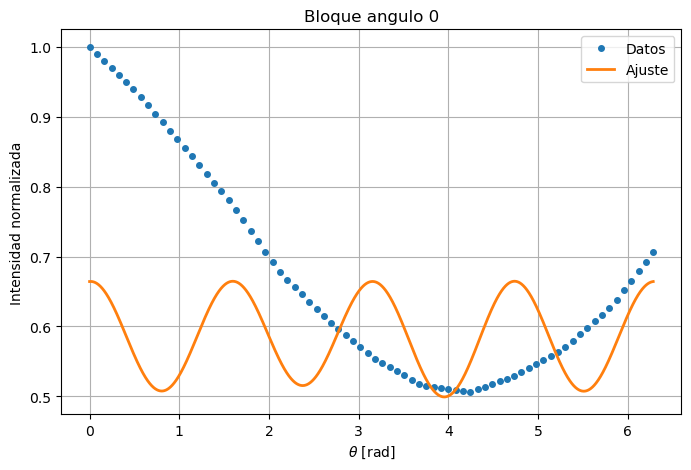

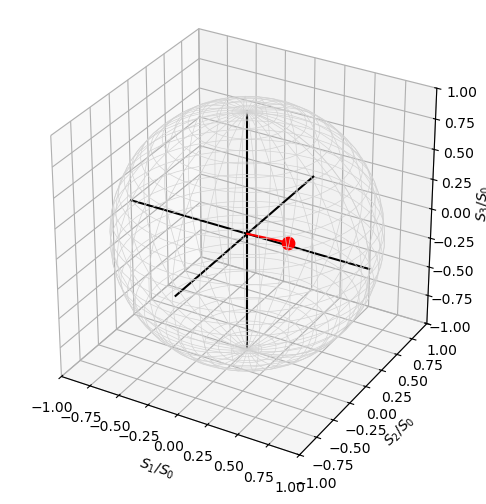

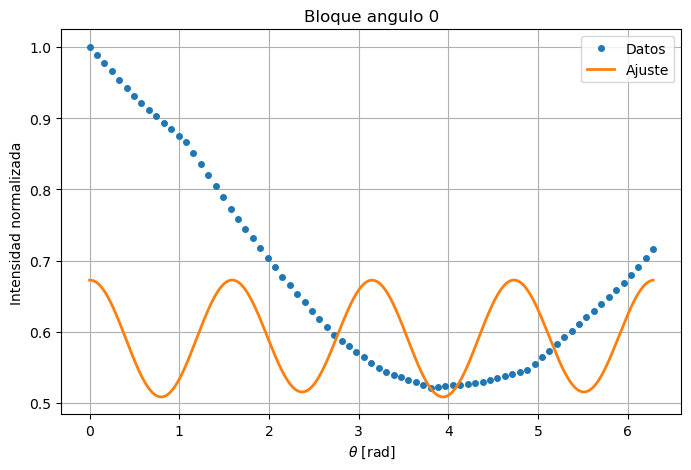

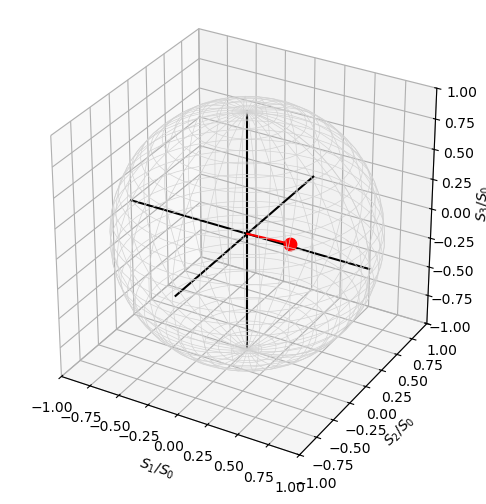

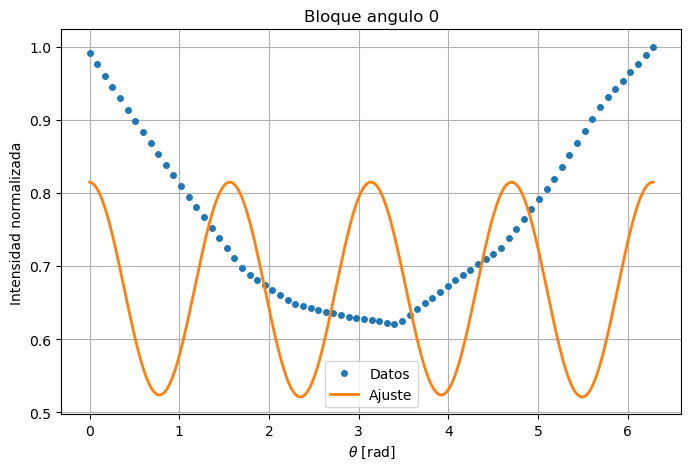

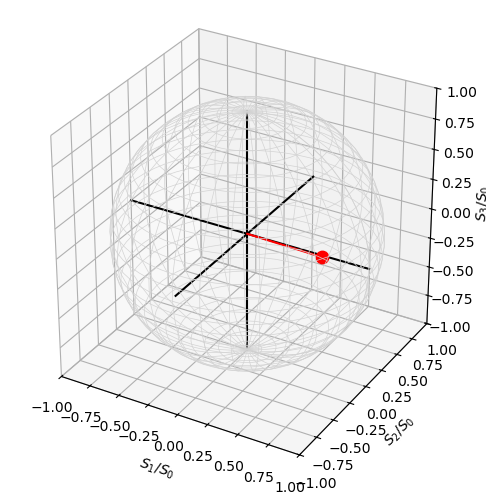

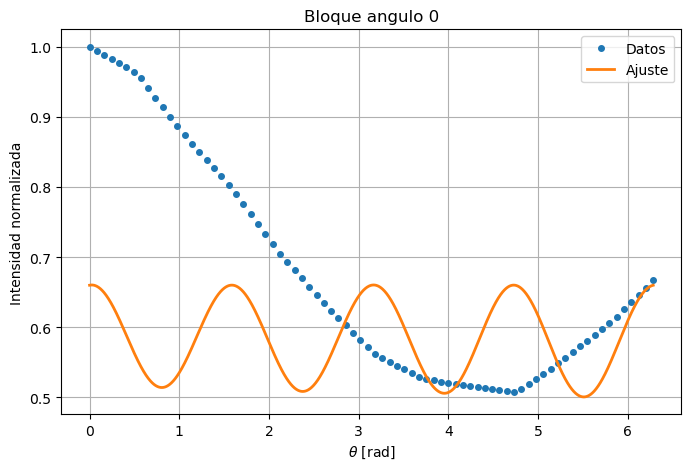

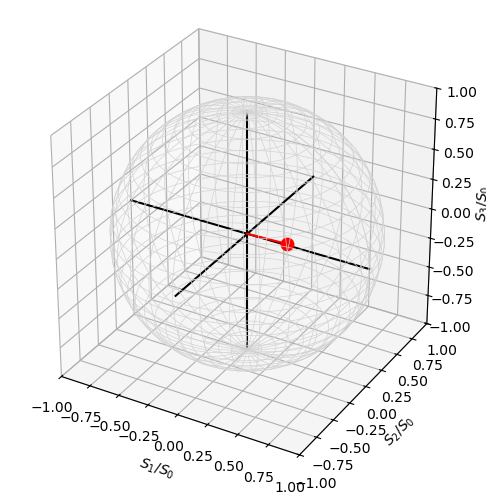

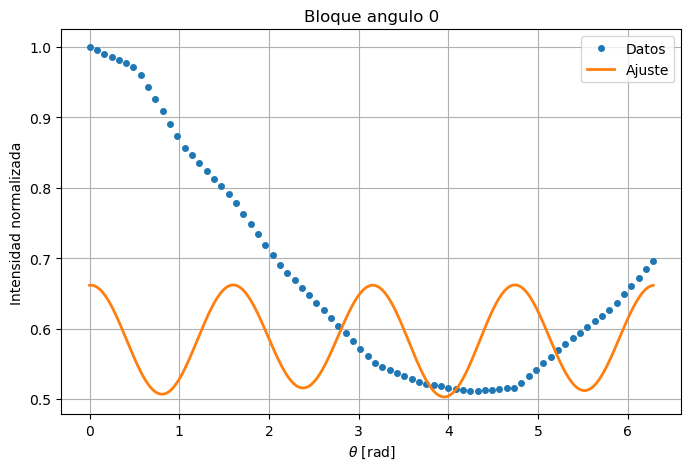

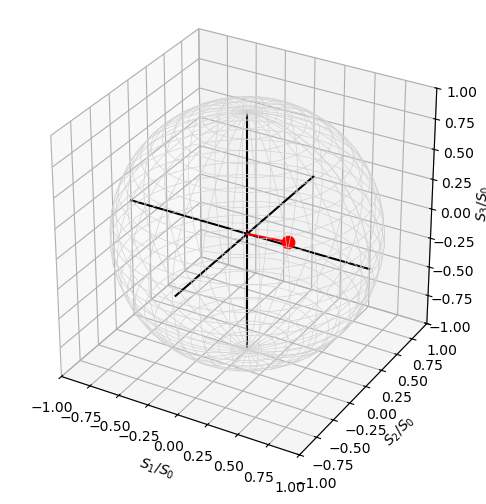

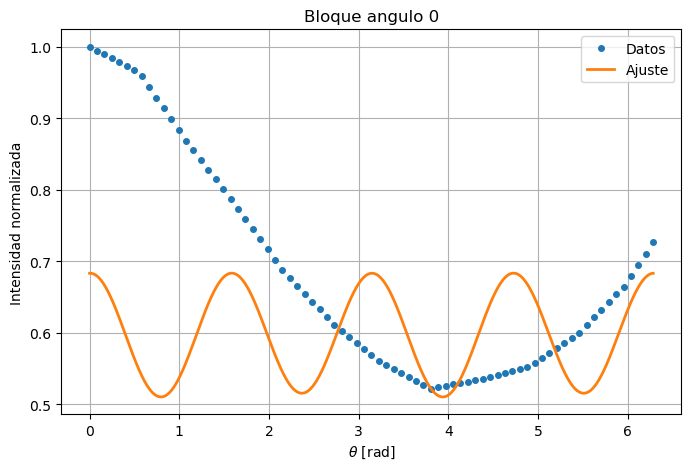

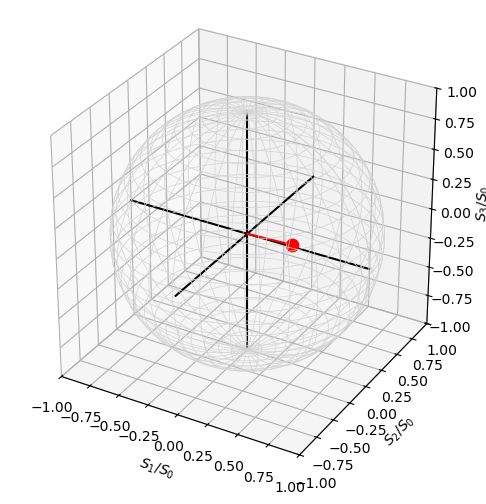

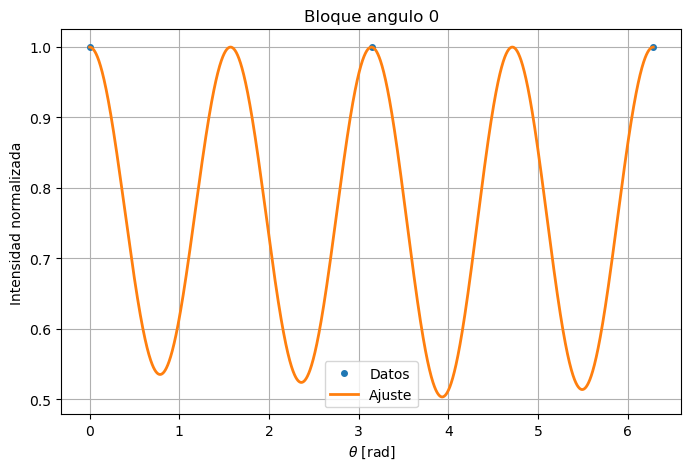

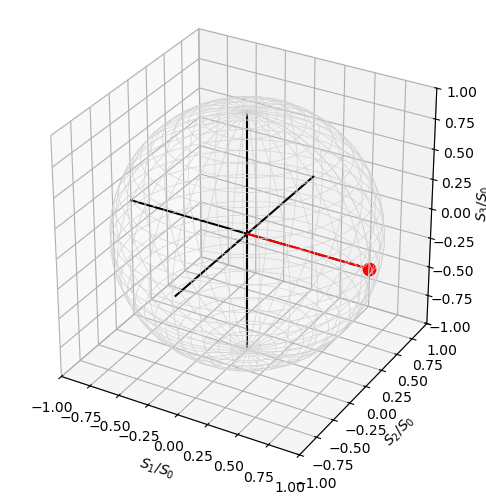

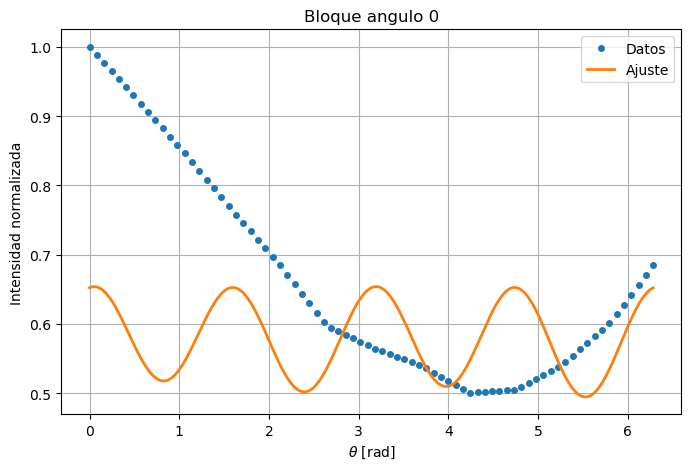

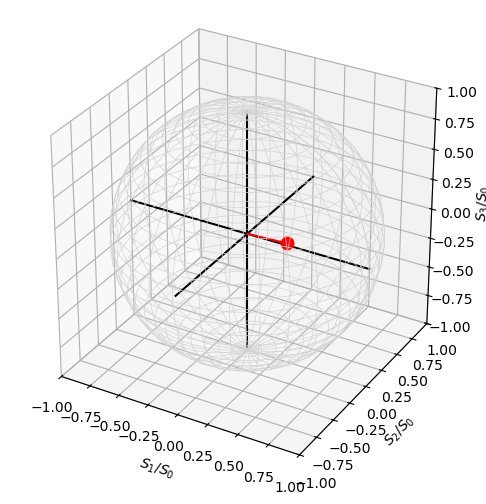

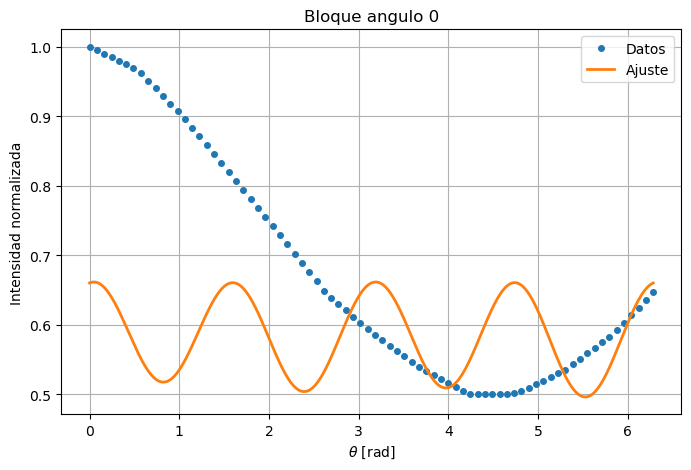

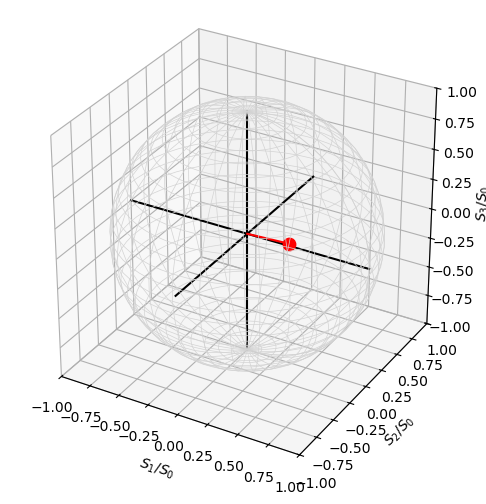

In [7]:
for pf in dfs:

    time = pf["tiempo_us"].to_numpy()
    voltaje = pf["voltaje_V"].to_numpy()
    vueltas = pf["vuelta"].to_numpy()


    theta_common = np.linspace(
        0,
        2*np.pi,
        500
    )

    numero = list(range(1, 3))

    I_all = []

    for n in numero:

        t = time[vueltas == vueltas[n]]
        I = voltaje[vueltas == vueltas[n]]

        idx = np.argsort(t)

        t = t[idx]
        I = I[idx]

        # ángulo de la vuelta
        theta= (
            2*np.pi
            * (t - t.min())
            / (t.max() - t.min())
        )

        I_interp = np.interp(
            theta_common,
            theta,
            I
        )

        I_all.append(I_interp)

    I_all = np.array(I_all)

    # promedio

    I_mean = np.mean(
        I_all,
        axis=0
    )

    I_std = np.std(
        I_all,
        axis=0
    )


    resultado = fit_una_vuelta_angulo_thetafijo(theta, I_mean,theta0_fijo=0, titulo=f"Bloque angulo 0")